In [3]:
import numpy as np
import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt

data_path = 'data'
val_path = 'val_one_channel'

In [2]:
os.listdir(f'{data_path}')[:5]

['J0239-0234_X_2008_04_02_pus_map.png',
 'J1529+6934_S_2017_07_16_pet_map.png',
 'J0403-3605_X_1997_03_31_fey_map.png',
 'J2033+2146_U_2017_07_30_moj_map.png',
 'J1354-2443_X_2015_10_16_pet_map.png']

(256, 256, 4)


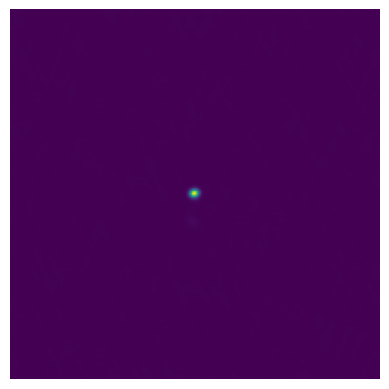

In [5]:
source =  'J0239-0234_X_2008_04_02_pus_map.png'
im = Image.open(f'{data_path}/{source}')
print(np.array(im).shape)
plt.imshow(im, cmap="gray")
plt.axis('off')
plt.show()

In [18]:
os.listdir(f'{val_path}/{2}')[:5]

['J0237+2848_S_2003_07_09_nic_map.png',
 'J1751+0939_X_1998_12_21_fey_map.png',
 'J2158-1501_U_2008_09_12_moj_map.png',
 'J0204+1514_K_2006_07_09_fey_map.png',
 'J0203+7232_X_2017_03_27_pet_map.png']

In [4]:
def map_noise(data, k=0.1) -> float:
    b1, b2 = int(k * data.shape[0]), int(k * data.shape[1])
    b3, b4 = int((1-k) * data.shape[0]), int((1-k) * data.shape[1])
    upper_left = np.std(data[:b1, :b2])
    upper_right = np.std(data[b3:, :b2])
    down_left = np.std(data[:b1, b4:])
    down_right = np.std(data[b3:, b4:])
    noise = np.median([upper_left, upper_right, down_left, down_right])
    return noise

(512, 512) 0.0


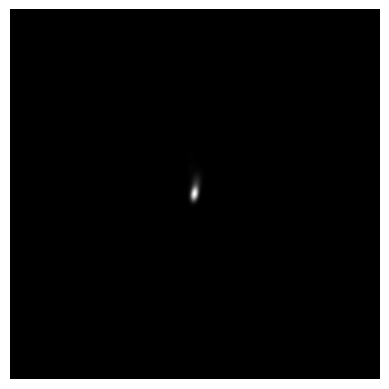

In [19]:
from PIL import Image
import matplotlib.pyplot as plt

source =  'J0237+2848_S_2003_07_09_nic_map.png'
im = Image.open(f'{val_path}/{2}/{source}')
print(np.array(im).shape, map_noise(np.array(im)))
plt.imshow(im, cmap="gray")
plt.axis('off')
plt.show()

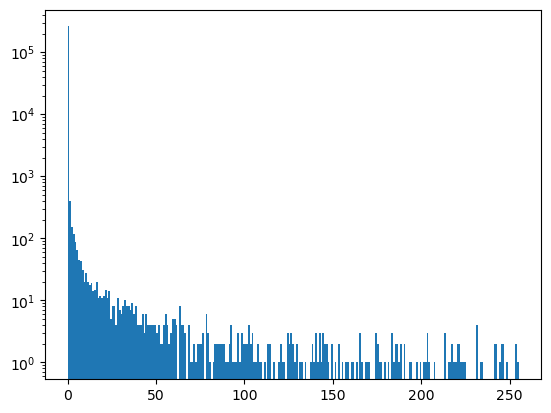

In [20]:
plt.hist(np.array(im).ravel(), bins=range(0, 256))
plt.yscale('log')
plt.show()

0.0


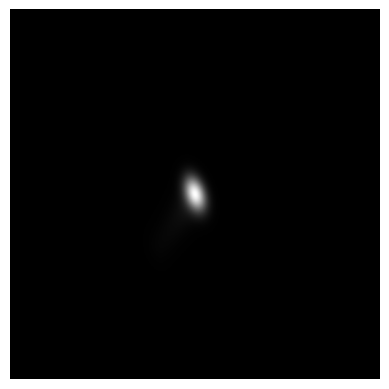

In [21]:
syntetic_path = 'synt_one_channel'
source = '1.png'

im = np.array(Image.open(f'{syntetic_path}/{2}/{source}'))
im = im.clip(min=0)
im = (im / im.max() * 255).astype(np.uint8)
print(map_noise(im))
im = Image.fromarray(im)
plt.imshow(im, cmap="gray")
plt.axis('off')
plt.show()

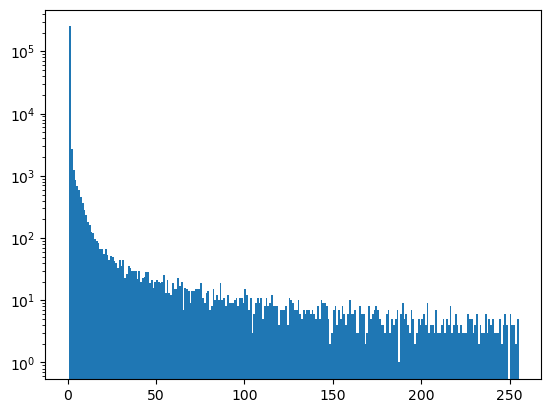

In [22]:
plt.hist(np.array(im).ravel(), bins=range(0, 256))
plt.yscale('log')
plt.show()

In [11]:
# import torchvision.transforms.functional as F
# import torch
# import torchvision.transforms.v2 as v2

# # contast = v2.RandomAutocontrast(p=0.5)
# # im = contast(im)
# norm = v2.Normalize(mean=(0,), std=(1,))
# im = norm((F.pil_to_tensor(im).to(float)))
# plt.imshow(im, cmap="gray")
# plt.axis('off')
# plt.show()